## Simple text processing with Python

Outline:
- Working with strings
- f-strings
- Reading/writing files
- Working with dictionaries
- Other tools

## Strings
Anything within ``quotes'' is a string!


In [ ]:
s = ' This is a string '
s = " This too! "
s = """ This one too! """
s = ''' And one more! '''

### Strings
Why so many?


In [ ]:
s = ' "Do or do not.  No try." said Yoda.'
s = " ' is a mighty lonely quote."
# The triple quoted ones can span multiple lines!

In [ ]:
s = """ The quick brown
fox jumped over
    the lazy dog.
"""

### Accessing part of strings


In [1]:
w = "hello"
print(w[0], w[1], w[-1])

h e o


In [2]:
len(w)

5

### Strings are immutable

In [3]:
w[0] = 'H'

TypeError: 'str' object does not support item assignment

### String operations


In [1]:
s = 'Hello'
p = 'World'
s + p

'HelloWorld'

In [2]:
s * 4

'HelloHelloHelloHello'

In [3]:
s * s

TypeError: can't multiply sequence by non-int of type 'str'

### String methods


In [ ]:
a = 'Hello World'
a.startswith('Hell')

In [ ]:
a.endswith('ld')

In [ ]:
a.upper()

In [ ]:
a.lower()

In [ ]:
a = '  Hello World  '
b = a.strip()
b

In [ ]:
b.index('ll')

In [ ]:
b.find('lz')

In [ ]:
b.replace('Hello', 'Goodbye')

## Strings:`split` & `join`


In [4]:
chars = 'a b c'
chars.split()

['a', 'b', 'c']

In [5]:
' '.join(['a', 'b', 'c'])

'a b c'

In [6]:
alpha = ', '.join(['a', 'b', 'c'])
alpha

'a, b, c'

In [7]:
alpha.split(', ')

['a', 'b', 'c']

### String formatting


In [ ]:
x, y = 1, 1.234
'x is %s, y is %s' % (x, y)

- `%d` , `%f`  etc. available

### f-strings

Much easier to use and super convenient. Let us see some examples:

In [5]:
name = 'Ram'
age = 25
wt = 60
print(f'{name} is {age} and weighs {wt} kgs')

Ram is 25 and weighs 60 kgs


In [6]:
def f(x):
    print(f'x is {x}; name is {name}')
f(1.0)

x is 1.0; name is Ram


In [7]:
print(r'\n hello')  # raw strings

\n hello


- Notice the use of the `f` in front of the string, can also use `F`.
- You can do more!

In [8]:
F'{name.upper()} is {age + 1} and weighs {wt + 0.5} kgs.'

'RAM is 26 and weighs 60.5 kgs.'


- Can also use format string specifiers to control things

In [ ]:
f'{name} is {age:d} and weighs {wt:.1f} kgs.'

- Can also introduce padding of the strings.

In [ ]:
f'{name:10} is {age:d} and weighs {wt:.1f} kgs.'

### More documentation on f-strings

- [f-string docs](https://docs.python.org/3/reference/lexical_analysis.html#formatted-string-literals)
- [Format specification](https://docs.python.org/3/library/string.html#formatspec)

### String containership


In [ ]:
fruits = 'apple, banana, pear'
'apple' in fruits

In [ ]:

'potato' in fruits

## Exercise 1
Given a 2 digit integer `x` , find the digits of the number.

* For example, let us say `x = 38`
* Find a way to get `a = 3` and `b = 8` using `x` ?


### Possible Solution


In [9]:
x = 38
a = x//10
b = x % 10
a*10 + b == x

True

### Another Solution


In [11]:
sx = str(x)
for i in sx:
    print(i)
a = int(sx[0])
b = int(sx[1])
a*10 + b == x

3
8


True

### Exercise 2
Given an arbitrary integer, count the number of digits it has.


### Possible solution


In [12]:
x = 12345678
len(str(x))  # Sneaky solution!

8

## Reading/writing files

- This is a high-level and limited introduction.
- Start by reading a simple text file, `data.txt`.

In [13]:
f = open('../data/data.txt')
data = f.read()
f.close()
type(data), len(data)

(str, 5000)

In [ ]:
# Same as:
f = open('../data/data.txt', 'r')  # mode defaults to 'r'
data = f.read()
f.close()

In [14]:
# Can also read them line-by-line
f = open('../data/data.txt')
data = f.readlines()
f.close()
type(data), len(data)

(list, 100)


- We must always close a file once we are done with it.
- OS has limits on number of open files.
- Sometimes others cannot use the file when someone else is writing to it
  etc.

Python provides a convenient syntax for these kind of things.

In [1]:
with open('../data/data.txt') as f:
    data = f.readlines()
print(len(data))
data[0]


100


'6.930830303506971291e+01 1.950570203348928500e+00\n'

- `with` introduces a new block.
- Notice the `as f` syntax carefully.
- Closes the file automatically on exit.
- Every line also has a line-ending character at the end, see the `'\n'` at
  the end.

### Writing files
- Easy to write files too
- Use the mode argument and set it to 'w'
- **Beware this will clobber the file**

In [ ]:
with open('/tmp/junk.txt', 'w') as f:
    f.write('Hello world!\n')

In [ ]:
# Can also do
with open('/tmp/junk.txt', 'w') as f:
    f.writelines(data)

- Note that `f.writelines` does not add a newline to the line.

### Exercise
- Read the data file, `../data/data.txt`
- Write every alternate line to a new data file called `junk.txt`

In [ ]:
# Solution
with open('../data/data.txt') as f:
    data = f.readlines()
    with open('../tmp/junk.txt','w') as w:
        for i in range(0, len(data), 2):
            w.writelines(data[i])

### Counting words in a string

Consider the following words in a paragraph from a famous novel: "Alice in
Wonderland" by Lewis Carroll.

In [8]:
para = """
Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do: once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, 'and what
is the use of a book,' thought Alice 'without pictures or conversations?'
"""


We now want to do a simple count of the words seen in this paragraph. We
want to know what is the most frequent word etc. How would we do this?

If we know a specific word it is easy to do this, for example, how often do
the words, "Alice", "the", "her" occur?

In [9]:
para.lower().count('alice')

2

In [10]:
para.lower().count('the')

3


We want more, we want to see all the words and count them all! We can do
this easily with a more powerful data type called the dictionary.

## Working with dictionaries
- Think of a dictionary as a container with keys and values.
- Keys can be strings, integers, floats etc. Basically any immutable quantity.
- Values can be anything.

Here is a simple example:

In [11]:
phonebook = {"mom": 1234, "dad": 5678}
phonebook

{'mom': 1234, 'dad': 5678}

In [12]:
type(phonebook)

dict

In [13]:
phonebook['mom']

1234

In [14]:
# Setting values
phonebook['mom'] = 4567
phonebook

{'mom': 4567, 'dad': 5678}

In [21]:
phonebook["work"] =  1022
phonebook

{'mom': 1234, 'dad': 5678, 'work': 1022}

In [24]:
# No need for fixed types:
d = {1: 25, 'a': 1.23, 'b': 'hello', 1.23: 'a'}
d

{1: 25, 'a': 1.23, 'b': 'hello', 1.23: 'a'}

In [ ]:
empty = {}
# or
empty = dict()

In [ ]:
# Can also do:
x = dict(x=1, y=2.1, zeta='hello')
x

In [25]:
# Iteration is easy
for key in d:
    print(key, d[key])

1 25
a 1.23
b hello
1.23 a


In [26]:
# Also
for key, value in d.items():
    print(key, value)

1 25
a 1.23
b hello
1.23 a


In [27]:
d.keys()

dict_keys([1, 'a', 'b', 1.23])

In [28]:
d.values()

dict_values([25, 1.23, 'hello', 'a'])

In [29]:
# Deletion
del d['b']
d

{1: 25, 'a': 1.23, 1.23: 'a'}

In [31]:
d.get('x', -1)

-1

### Other methods

- `d.clear()`
- `d.copy()`
- `d.fromkeys(iterable, value=None)`
- `d.get(key)`
- `d.pop()`/`d.popitem()`
- `d.setdefault(key, default=None)`
- `d.update(...)`: Update with a dict/iterable

In [32]:
dict.fromkeys(range(5), 0)

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

Returning to our task of counting words in the string s


In [5]:
# Solution
data = {}
for word in para.lower().split():
    if word in data:
        data[word] += 1
    else:
        data[word] = 1
data

{'alice': 2,
 'was': 2,
 'beginning': 1,
 'to': 2,
 'get': 1,
 'very': 1,
 'tired': 1,
 'of': 3,
 'sitting': 1,
 'by': 1,
 'her': 2,
 'sister': 2,
 'on': 1,
 'the': 3,
 'bank,': 1,
 'and': 1,
 'having': 1,
 'nothing': 1,
 'do:': 1,
 'once': 1,
 'or': 3,
 'twice': 1,
 'she': 1,
 'had': 2,
 'peeped': 1,
 'into': 1,
 'book': 1,
 'reading,': 1,
 'but': 1,
 'it': 1,
 'no': 1,
 'pictures': 2,
 'conversations': 1,
 'in': 1,
 'it,': 1,
 "'and": 1,
 'what': 1,
 'is': 1,
 'use': 1,
 'a': 1,
 "book,'": 1,
 'thought': 1,
 "'without": 1,
 "conversations?'": 1}

There is a problem with the punctuation marks!
- We want to delete any punctuation
- We want to remove additional spaces

Can use some string methods to do this.
- Specifically, we can use `para.translate`
- Takes a table (dictionary) with text replacement

In [6]:
# Using para.translate
table = {':': None, ',': None, '?': None}
t = para.maketrans(table)
para.translate(t)

"\nAlice was beginning to get very tired of sitting by her sister on the bank\nand of having nothing to do once or twice she had peeped into the book her\nsister was reading but it had no pictures or conversations in it 'and what\nis the use of a book' thought Alice 'without pictures or conversations'\n"

- But we want to remove all punctuation
- The `string` module is very convenient

In [15]:
import string

In [16]:
string.ascii_letters

'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [17]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
string.whitespace

' \t\n\r\x0b\x0c'

In [19]:
# Now we are good to go:
table = dict.fromkeys(string.punctuation)
para.translate(para.maketrans(table))

'\nAlice was beginning to get very tired of sitting by her sister on the bank\nand of having nothing to do once or twice she had peeped into the book her\nsister was reading but it had no pictures or conversations in it and what\nis the use of a book thought Alice without pictures or conversations\n'

### Exercise: Counting words in Alice in Wonderland

- Take the text file provided in `../data/alice.txt`
- Read the entire novel and clean up the data of punctuation etc.
- Normalize the whitespace to a single space
- Do a full word count
- Show the top 10 words in the text
- Can show a histogram of the top words etc.
- What is the longest word in the book?

Top 10 words:[('the', 1613), ('and', 789), ('to', 711), ('a', 619), ('she', 521), ('of', 496), ('said', 425), ('it', 367), ('in', 352), ('was', 333)]
the: 1613
and: 789
to: 711
a: 619
she: 521
of: 496
said: 425
it: 367
in: 352
was: 333
26690
{"alice's": 11, 'adventures': 5, 'in': 352, 'wonderland': 2, 'lewis': 1, 'carroll': 1, 'the': 1613, 'millennium': 1, 'fulcrum': 1, 'edition': 1, '3.0': 1, 'chapter': 12, 'i.': 1, 'down': 79, 'rabbit-hole': 4, 'alice': 221, 'was': 333, 'beginning': 12, 'to': 711, 'get': 43, 'very': 139, 'tired': 7, 'of': 496, 'sitting': 10, 'by': 57, 'her': 208, 'sister': 5, 'on': 142, 'bank,': 2, 'and': 789, 'having': 10, 'nothing': 22, 'do:': 2, 'once': 21, 'or': 70, 'twice': 2, 'she': 521, 'had': 176, 'peeped': 3, 'into': 67, 'book': 3, 'reading,': 1, 'but': 122, 'it': 367, 'no': 68, 'pictures': 4, 'conversations': 1, 'it,': 38, "'and": 56, 'what': 91, 'is': 78, 'use': 16, 'a': 619, "book,'": 2, 'thought': 63, "'without": 1, "conversations?'": 1, 'so': 129, 'cons

<BarContainer object of 10 artists>

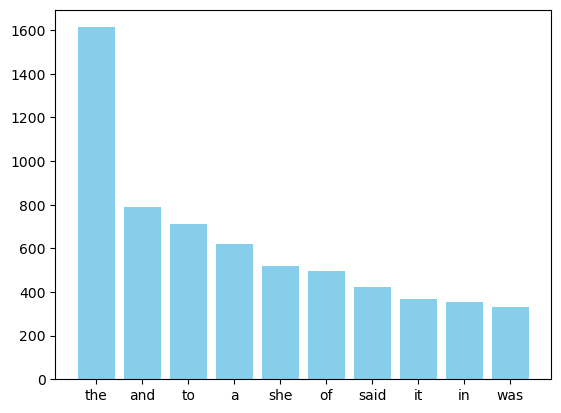

In [10]:
import string
import matplotlib.pyplot as plt
import numpy as np

punc = dict.fromkeys(string.punctuation)
whitespace = dict.fromkeys(string.whitespace)
wordCountDict={}
wordLengthDict={}
with open('../data/alice.txt', 'r') as f:
    line = f.read()
    line = line.replace("--", " ")
    line.translate(line.maketrans(punc))
    line.translate(line.maketrans(whitespace))
    for word in line.lower().split():
        if word in wordCountDict:
            wordCountDict[word]+=1
        else:
            wordLengthDict[word]=len(word)
            wordCountDict[word]=1

# Sort by frequency (descending) and take top 10
top_10 = sorted(wordCountDict.items(), key=lambda eachTuple: eachTuple[1], reverse=True)[:10]
top_1 = sorted(wordLengthDict.items(), key=lambda eachTuple: eachTuple[1], reverse=True)[:1]

top_10_words = []
top_10_count = []

print(F"Top 10 words:{top_10}")
for word, freq in top_10:
    top_10_words.append(word)
    top_10_count.append(freq)
    print(f"{word}: {freq}")

print(sum(wordCountDict.values()))
print(wordCountDict)
print(top_1)
plt.bar(top_10_words, top_10_count, color='skyblue')

## Other tools

Regular expressions are extremely useful for more complex text processing.
You can learn more about them from:
- https://docs.python.org/3/howto/regex.html
- https://docs.python.org/3/library/re.html

If you do decide to learn more about regular expressions, this website can
be extremely helpful when you are trying to learn, write, and debug your
regular expressions: https://pythex.org/ .